
Universidade do Vale do Itajaí <br>
Escola Politécnica <br>
Processamento Digital de Sinais: Imagens <br>

### Alunos: <br>
1.      Diogo Henrique Ribicki
2.      João Victor da Silva
3.      Pedro Henrique de Paula

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.util import random_noise

### Carregar o DataSet

In [4]:
data = np.load('data/chestmnist.npz')

### Separar os dados

In [5]:
train_images = data['train_images']
train_labels = data['train_labels']

print("Shape das imagens:", train_images.shape)
print("Shape dos labels:", train_labels.shape)

Shape das imagens: (78468, 28, 28)
Shape dos labels: (78468, 14)


### Selecionar imagens

In [6]:
img_1 = train_images[5]
img_2 = train_images[25]
img_3 = train_images[50]

### Exibir imagens

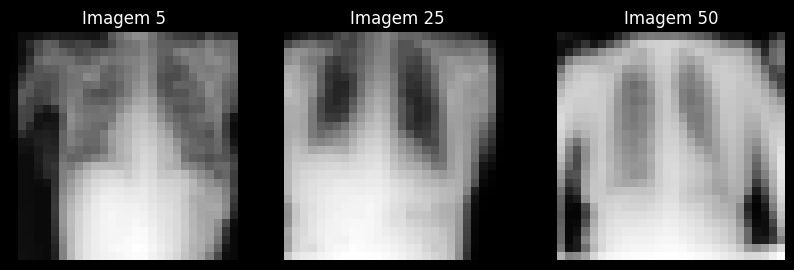

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_1, cmap='gray')
plt.title("Imagem 5")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_2, cmap='gray')
plt.title("Imagem 25")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_3, cmap='gray')
plt.title("Imagem 50")
plt.axis('off')

plt.show()

### Implementação do Trabalho

### Helpers

In [8]:
def show_images_grid(images, titles=None, cols=3, figsize=(12, 6)):
    n_images = len(images)
    rows = (n_images + cols - 1) // cols

    plt.figure(figsize=figsize)

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap='gray')

        if titles:
            plt.title(titles[i])

        plt.axis('off')

    plt.tight_layout()
    plt.show()

### 1 - Preparação das imagens

In [9]:
data = np.load('data/chestmnist.npz')

train_images = data['train_images']

img_1 = train_images[5].astype(np.float32)
img_2 = train_images[25].astype(np.float32)
img_3 = train_images[50].astype(np.float32)

### Funções para aplicar ruídos

In [10]:
def add_salt_pepper_noise(img, amount=0.05, salt_vs_pepper=0.5):
    noisy = img.copy()

    total_pixels = img.shape[0] * img.shape[1]
    num_noisy = int(total_pixels * amount)

    num_salt = int(num_noisy * salt_vs_pepper)
    num_pepper = num_noisy - num_salt

    # Salt (branco = 255)
    coords_salt = (
        np.random.randint(0, img.shape[0], num_salt),
        np.random.randint(0, img.shape[1], num_salt)
    )
    noisy[coords_salt] = 255

    # Pepper (preto = 0)
    coords_pepper = (
        np.random.randint(0, img.shape[0], num_pepper),
        np.random.randint(0, img.shape[1], num_pepper)
    )
    noisy[coords_pepper] = 0

    return noisy

In [11]:
def add_gaussian_noise(img, mean=0, std=15):
    noise = np.random.normal(mean, std, img.shape)
    noisy = img + noise
    noisy = np.clip(noisy, 0, 255)
    return noisy

### Cria as imagens com ruídos + exibição das imagens

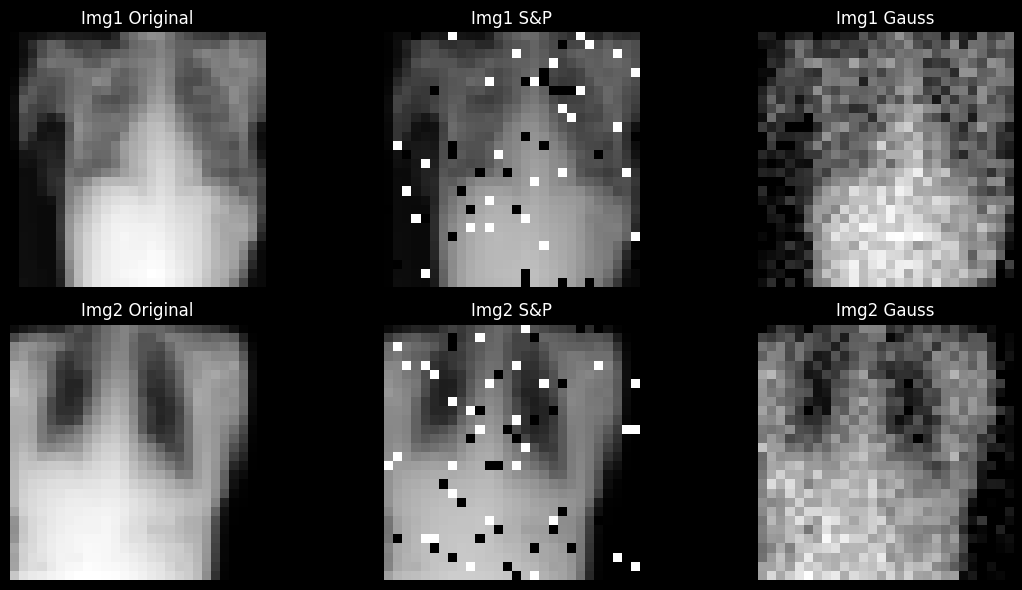

In [12]:
img_1_sp = add_salt_pepper_noise(img_1, amount=0.08)
img_2_sp = add_salt_pepper_noise(img_2, amount=0.08)
img_3_sp = add_salt_pepper_noise(img_3, amount=0.08)

img_1_gauss = add_gaussian_noise(img_1, std=20)
img_2_gauss = add_gaussian_noise(img_2, std=20)
img_3_gauss = add_gaussian_noise(img_3, std=20)

show_images_grid(
    [img_1, img_1_sp, img_1_gauss,
     img_2, img_2_sp, img_2_gauss],
    [
        "Img1 Original", "Img1 S&P", "Img1 Gauss",
        "Img2 Original", "Img2 S&P", "Img2 Gauss"
    ],
    cols=3
)

teste
